# Fine-tuned TrOCR Handwritten Text Recognition - Inference

This notebook demonstrates how to perform OCR inference on handwritten text images using our fine-tuned TrOCR model. You can process single images or batch process multiple images and view the results.

## 1. Import Required Libraries

In [2]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from transformers import VisionEncoderDecoderModel, TrOCRProcessor
import warnings
warnings.filterwarnings('ignore')

# Check device availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
GPU Memory Available: 4.29 GB


## 2. Load the Fine-Tuned TrOCR Model

We'll load our fine-tuned TrOCR model from the checkpoint saved after 10 epochs of training.

In [3]:
# Model paths
model_checkpoint = "trocr_handwritten/checkpoint-6770"  # Best checkpoint with CER 0.2302

print("Loading model and processor...")
model = VisionEncoderDecoderModel.from_pretrained(model_checkpoint)
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-small-handwritten")

# Move model to device
model.to(device)
model.eval()

print(f"✓ Model loaded successfully from {model_checkpoint}")
print(f"✓ Model is in eval mode")
print(f"Model config: {model.config.to_dict()['decoder']}")

Loading model and processor...


Loading weights: 100%|██████████| 362/362 [00:00<00:00, 5249.99it/s]


✓ Model loaded successfully from trocr_handwritten/checkpoint-6770
✓ Model is in eval mode
Model config: {'architectures': None, 'output_hidden_states': False, 'return_dict': True, 'dtype': 'float32', 'chunk_size_feed_forward': 0, 'is_encoder_decoder': False, 'id2label': {0: 'LABEL_0', 1: 'LABEL_1'}, 'label2id': {'LABEL_0': 0, 'LABEL_1': 1}, 'problem_type': None, 'vocab_size': 64044, 'd_model': 256, 'decoder_layers': 6, 'decoder_attention_heads': 8, 'decoder_ffn_dim': 1024, 'activation_function': 'relu', 'max_position_embeddings': 512, 'dropout': 0.1, 'attention_dropout': 0.0, 'activation_dropout': 0.0, 'decoder_start_token_id': 2, 'init_std': 0.02, 'decoder_layerdrop': 0.0, 'use_cache': False, 'scale_embedding': True, 'use_learned_position_embeddings': True, 'layernorm_embedding': True, 'pad_token_id': 1, 'bos_token_id': 0, 'eos_token_id': 2, 'cross_attention_hidden_size': 384, 'is_decoder': True, 'tie_word_embeddings': False, '_name_or_path': '', 'add_cross_attention': True, 'classif

## 3. Define OCR Inference Function

In [4]:
def perform_ocr(image_path):
    """
    Perform OCR on a single image using the fine-tuned TrOCR model.
    
    Args:
        image_path (str): Path to the image file
        
    Returns:
        tuple: (image, text) - PIL Image object and extracted text
    """
    # Load and prepare image
    image = Image.open(image_path).convert('RGB')
    
    # Process image with TrOCR processor
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)
    
    # Generate text predictions
    with torch.no_grad():
        generated_ids = model.generate(pixel_values, num_beams=4)
    
    # Decode to text
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    
    return image, generated_text

def visualize_ocr_result(image, text, title="OCR Result"):
    """
    Display image and its OCR result side by side.
    
    Args:
        image (PIL.Image): Image object
        text (str): OCR result text
        title (str): Figure title
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Display image
    ax1.imshow(image)
    ax1.axis('off')
    ax1.set_title('Input Image')
    
    # Display text result
    ax2.axis('off')
    ax2.text(0.1, 0.5, f"Recognized Text:\n\n{text}", 
             fontsize=12, verticalalignment='center', 
             fontfamily='monospace', wrap=True)
    ax2.set_title('OCR Output')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("✓ OCR functions defined successfully")

✓ OCR functions defined successfully


## 4. Perform OCR on Single Image

Choose a single test image and perform OCR inference on it.

In [5]:
# List available test images
test_image_dir = Path("input/gnhk_dataset/test_processed/images")
image_files = sorted(list(test_image_dir.glob("*.jpg")))

print(f"Total test images available: {len(image_files)}")
print(f"\nFirst 5 test images:")
for i, img_file in enumerate(image_files[:5]):
    print(f"  {i+1}. {img_file.name}")

# Select first image for single inference
sample_image_path = image_files[0]
print(f"\n--- Processing: {sample_image_path.name} ---")

# Perform OCR
image, text = perform_ocr(str(sample_image_path))
print(f"✓ OCR Complete")
print(f"Recognized Text: {text}")

Total test images available: 10066

First 5 test images:
  1. eng_AF_004_0.jpg
  2. eng_AF_004_1.jpg
  3. eng_AF_004_10.jpg
  4. eng_AF_004_11.jpg
  5. eng_AF_004_12.jpg

--- Processing: eng_AF_004_0.jpg ---
✓ OCR Complete
Recognized Text: what


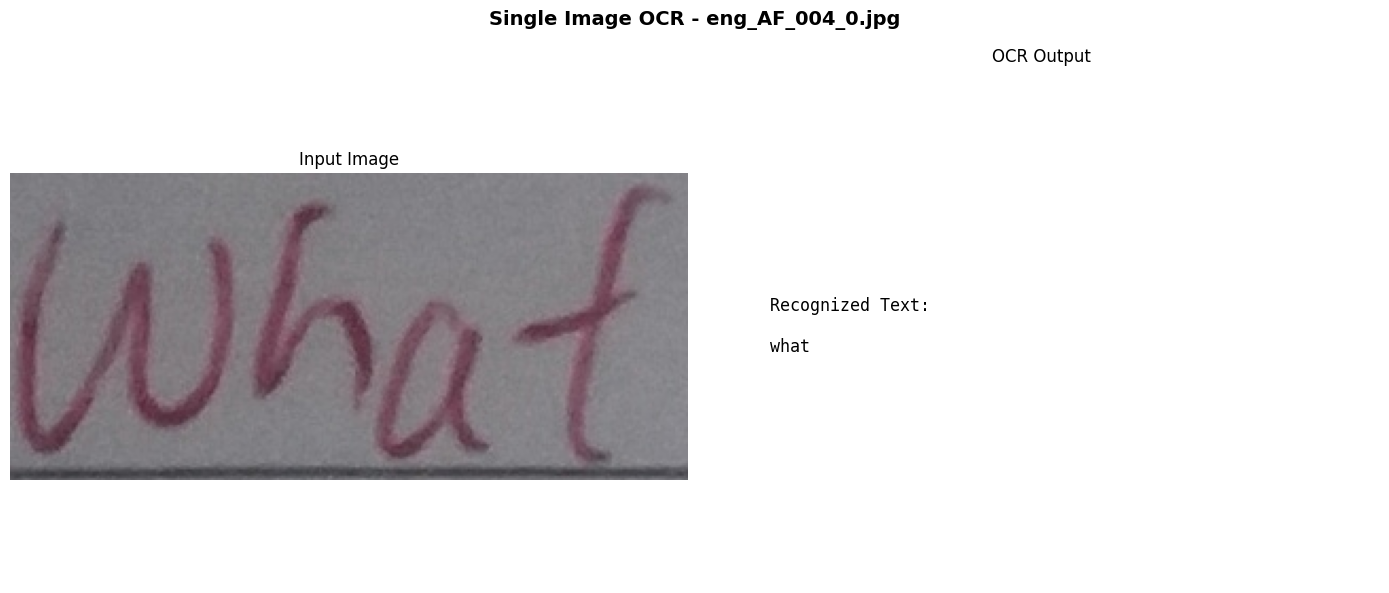

In [7]:
# Visualize the result
visualize_ocr_result(image, text, title=f"Single Image OCR - {sample_image_path.name}")

## 5. Batch Inference on Multiple Images

Process multiple images at once and display results in a grid.

In [8]:
# Set number of images to process
num_samples = 10
sample_images = image_files[:num_samples]

print(f"Processing {num_samples} sample images...")

# Process all images
results = []
for idx, img_path in enumerate(sample_images):
    try:
        image, text = perform_ocr(str(img_path))
        results.append({
            'path': img_path,
            'name': img_path.name,
            'image': image,
            'text': text
        })
        print(f"✓ {idx+1}/{num_samples}: {img_path.name} -> '{text}'")
    except Exception as e:
        print(f"✗ {idx+1}/{num_samples}: {img_path.name} - Error: {str(e)}")

print(f"\nSuccessfully processed {len(results)} images")

Processing 10 sample images...
✓ 1/10: eng_AF_004_0.jpg -> 'what'
✓ 2/10: eng_AF_004_1.jpg -> 'I'
✓ 3/10: eng_AF_004_10.jpg -> '(D'
✓ 4/10: eng_AF_004_11.jpg -> 'improve'
✓ 5/10: eng_AF_004_12.jpg -> 'my'
✓ 6/10: eng_AF_004_13.jpg -> 'and'
✓ 7/10: eng_AF_004_14.jpg -> 'writing'
✓ 8/10: eng_AF_004_15.jpg -> '(2'
✓ 9/10: eng_AF_004_16.jpg -> 'learn'
✓ 10/10: eng_AF_004_17.jpg -> 'how'

Successfully processed 10 images


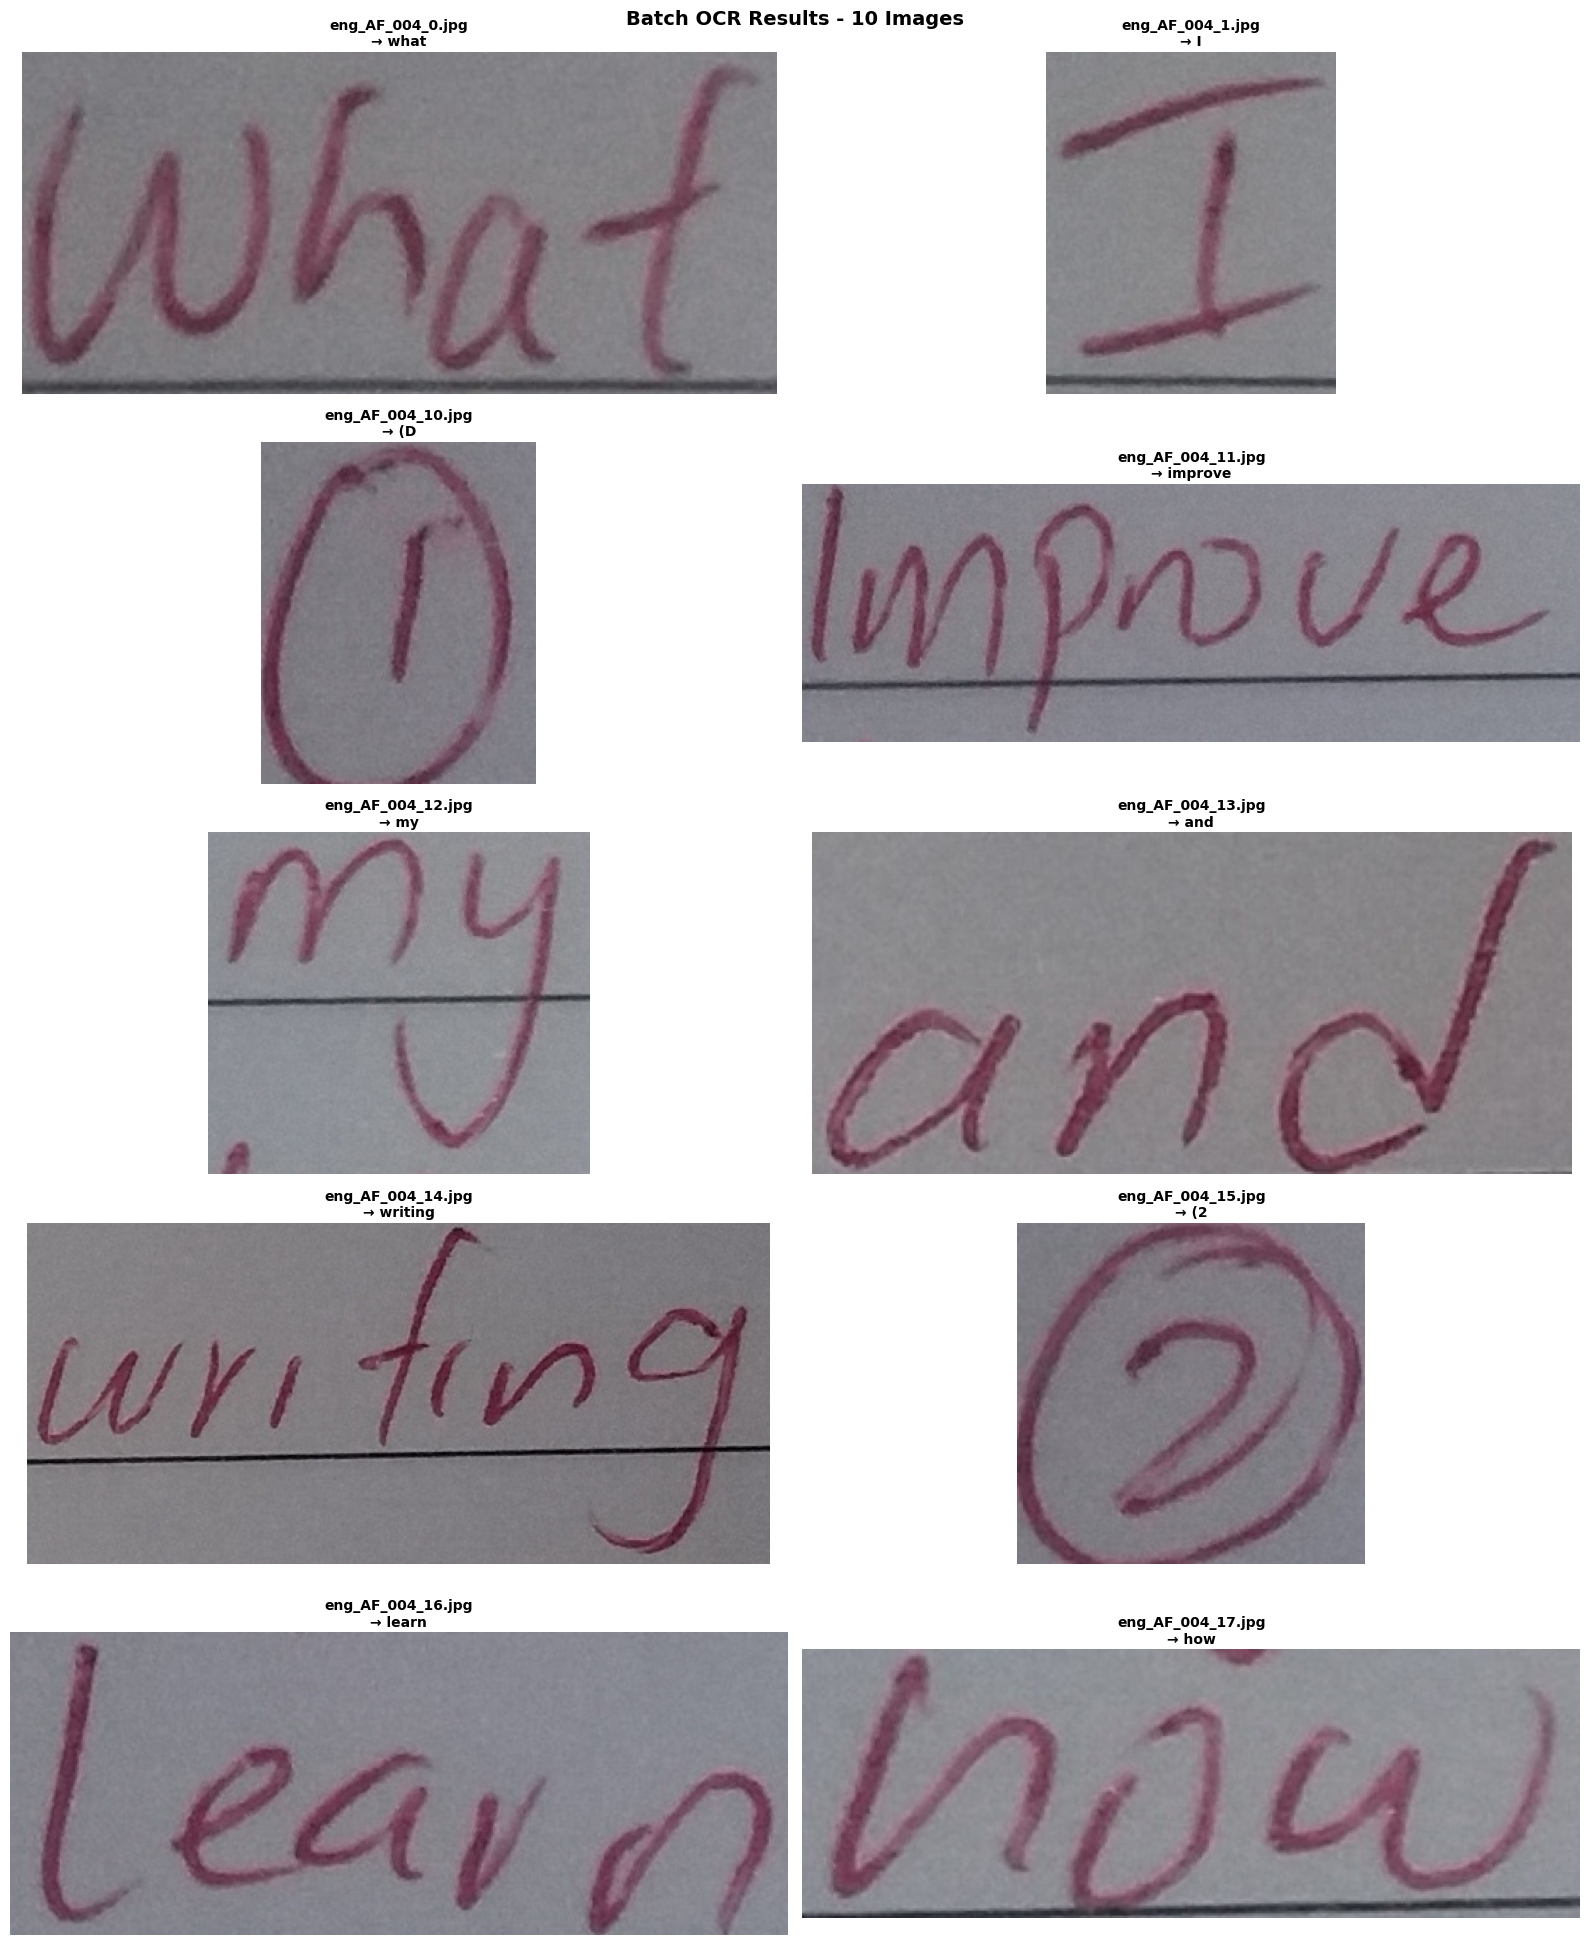

In [9]:
# Display results in a grid
rows = (len(results) + 1) // 2
fig, axes = plt.subplots(rows, 2, figsize=(16, 4*rows))

if rows == 1:
    axes = axes.reshape(1, -1)

for idx, result in enumerate(results):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Display image
    ax.imshow(result['image'])
    ax.axis('off')
    
    # Set title with image name and recognized text
    title = f"{result['name']}\n→ {result['text']}"
    ax.set_title(title, fontsize=10, fontweight='bold', wrap=True)

# Hide empty plots
for idx in range(len(results), rows * 2):
    row = idx // 2
    col = idx % 2
    axes[row, col].axis('off')

plt.suptitle(f"Batch OCR Results - {len(results)} Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Process a Custom Image (Optional)

To process your own image, update the image path below and run the cell.

Processing custom image: input/customtest2.jpeg
✓ OCR Complete
Recognized Text: 'God'


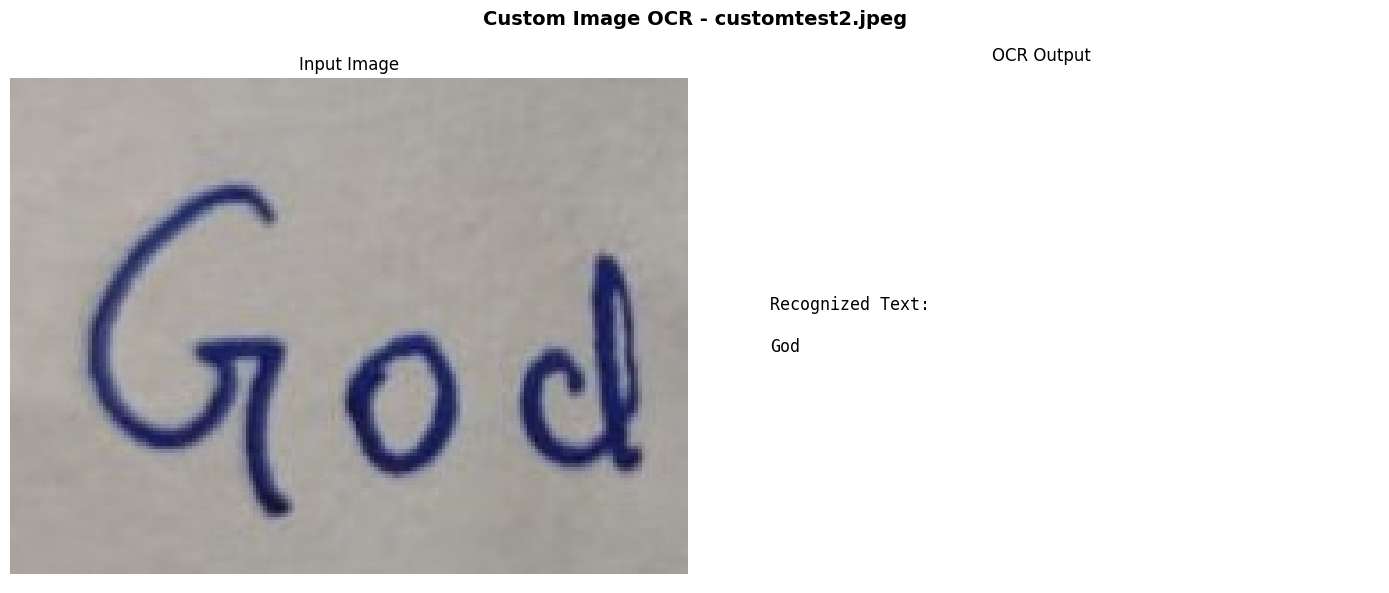

In [14]:
# Modify this path to use your own image
custom_image_path = str("input/customtest2.jpeg")  # Change to any image path or file path

print(f"Processing custom image: {custom_image_path}")

try:
    image, text = perform_ocr(custom_image_path)
    print(f"✓ OCR Complete")
    print(f"Recognized Text: '{text}'")
    
    # Visualize
    visualize_ocr_result(image, text, title=f"Custom Image OCR - {Path(custom_image_path).name}")
except FileNotFoundError:
    print(f"✗ Image not found at: {custom_image_path}")
except Exception as e:
    print(f"✗ Error processing image: {str(e)}")

## 6.1. Upload and OCR a Single Word Image
Upload a single handwritten word image and click the button to display the OCR result.

In [16]:
pip install ipywidgets


   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 914.9/914.9 kB 5.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   --------------------------------- ------ 1.8/2.2 MB 11.2 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 6.5 MB/s  0:00:00

   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   ---------------------------------------- 3/3 [ipywidgets]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import io
import ipywidgets as widgets
from IPython.display import display, clear_output


def perform_ocr_image(image):
    """Perform OCR on a PIL.Image object."""
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)
    with torch.no_grad():
        generated_ids = model.generate(pixel_values, num_beams=4)
    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

upload_widget = widgets.FileUpload(
    accept='image/*',
    multiple=False,
    description='Upload Image'
)
run_button = widgets.Button(description='Run OCR', button_style='success')
output = widgets.Output()


def on_run_clicked(b):
    with output:
        clear_output()
        if not upload_widget.value:
            print("Please upload a single image file.")
            return
        uploaded = next(iter(upload_widget.value.values()))
        image_data = uploaded['content']
        try:
            image = Image.open(io.BytesIO(image_data)).convert('RGB')
            text = perform_ocr_image(image)
            display(image)
            print(f"✓ Recognized Text:\n{text}")
        except Exception as e:
            print(f"✗ Error during OCR: {e}")

run_button.on_click(on_run_clicked)

display(widgets.VBox([
    widgets.Label(value='Upload a handwritten word image below:'),
    upload_widget,
    run_button,
    output
]))

## 7. Export Results

Save the OCR results to a file for further analysis.

In [6]:
import csv
from datetime import datetime

# Create output directory if it doesn't exist
output_dir = Path("inference_results")
output_dir.mkdir(exist_ok=True)

# Export results to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_file = output_dir / f"ocr_results_{timestamp}.csv"

with open(output_file, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['Image Name', 'OCR Result', 'Image Path'])
    
    for result in results:
        writer.writerow([
            result['name'],
            result['text'],
            str(result['path'])
        ])

print(f"✓ Results exported to: {output_file}")

# Display summary
print(f"\n--- OCR Results Summary ---")
for result in results:
    print(f"{result['name']}: {result['text']}")

✓ Results exported to: inference_results\ocr_results_20260405_174003.csv

--- OCR Results Summary ---
eng_AF_004_0.jpg: what
eng_AF_004_1.jpg: I
eng_AF_004_10.jpg: (D
eng_AF_004_11.jpg: improve
eng_AF_004_12.jpg: my
eng_AF_004_13.jpg: and
eng_AF_004_14.jpg: writing
eng_AF_004_15.jpg: (2
eng_AF_004_16.jpg: learn
eng_AF_004_17.jpg: how
